# Pseudobulk Differential Expression

> **Where this fits:** NB7c ran Wilcoxon rank-sum tests treating every cell as an independent observation. This notebook implements the methodologically correct alternative and shows concretely what changes.

## The pseudoreplication problem

The vWAT data has ~50,000 cells but only 3 mice per condition. Those 50,000 cells did not come from 50,000 independent biological replicates — they came from 3 mice. Cells within the same mouse share genetics, diet history, and batch effects. The Wilcoxon test in NB7c treated them as independent, inflating the effective sample size from 3 to ~16,000.

**ML analogy:** Evaluating a classifier by sampling 1,000 augmented crops from each of 3 test images. You report accuracy on 3,000 "test samples" but you have 3 independent test cases. Your confidence intervals are fake.

Benchmarking studies found that naive cell-level methods (Wilcoxon, t-test) produce false positive rates of 40–70% on multi-sample scRNA-seq data, compared to the nominal 5% (Squair et al. 2021, Junttila et al. 2022).

## The fix: pseudobulk

For each mouse × cell state combination, sum the raw counts of all cells in that group into one integer-count vector. This reduces 50,000 cells to 6 sample-level observations (3 SC mice + 3 SH mice) and then runs DESeq2 on those 6 observations — which is exactly what DESeq2 was designed for.

**ML analogy:** Multiple instance learning (MIL) bag-level aggregation. Instead of classifying each cell independently, you aggregate cell features into a mouse-level vector and classify that. The mouse (bag) is your unit of inference, not the cell (instance).

## The N=3 tradeoff

This dataset has 3 mice per condition in vWAT — the absolute minimum for DESeq2. The failure mode here is **low power**: you'll detect fewer DEGs than Wilcoxon, not because the effects aren't real but because N=3 can only detect large effects after correcting for testing 15,000 genes. What you *do* call significant is trustworthy — the FDR is correctly controlled. That's a conservative, interpretable failure, and the strongest defensible result you can report from this data.

## What we cover

| Step | What it does |
|------|--------------|
| Pseudobulk creation | Sum raw counts per mouse × cell state |
| EDA | PCA on pseudobulks to check for confounders |
| Obesity contrast | SH vs SC — effect of high-fat diet |
| Exercise contrast | TC vs SC — effect of training on healthy diet |
| Comparison | Overlap with NB7c Wilcoxon — which genes survive the stricter test? |

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc                      # single-cell analysis toolkit — our AnnData interface
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches   # for custom legend color patches
import seaborn as sns
from pathlib import Path
from scipy.sparse import issparse       # the count matrix is stored sparse to save memory
from sklearn.decomposition import PCA

# pydeseq2 is a pure-Python port of the R DESeq2 package.
# DeseqDataSet fits the model (size factors + dispersion).
# DeseqStats runs the statistical test for a specific contrast.
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

sc.settings.verbosity = 1
plt.rcParams['figure.dpi'] = 100

DATA_PATH = Path('../GSE183288_Single_cell_atlas.h5ad')
OUT_DIR   = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

# Gene sets from the paper — defined once here so every downstream cell can reference them
# ECM = extracellular matrix genes the paper found upregulated by obesity in IPC/CP states
# CIRCADIAN = clock genes the paper found upregulated by exercise in IPC/CP states
ECM_GENES       = ['Thbs1', 'Sparc', 'Col3a1', 'Col6a1', 'Col1a1', 'Col1a2']
CIRCADIAN_GENES = ['Dbp', 'Tef', 'Nr1d2', 'Per3', 'Hlf', 'Bmal1', 'Clock']

# Significance thresholds applied uniformly throughout
# LFC_THRESH is stricter than NB7c's 0.25 — appropriate given that N=3 has
# low power, so we only claim genes with a large enough effect to be credible
PADJ_THRESH = 0.05
LFC_THRESH  = 0.5

## Load the atlas and confirm the experimental design

Before touching any statistics, we need to know exactly how many independent biological replicates we have. This is the binding constraint: no statistical method can manufacture replicates that don't exist.

In this dataset the replicates are **mice**, not cells. Each mouse is an independent animal that was raised, fed, and sacrificed separately. Cells within the same mouse are correlated — they share that mouse's genome, microbiome, stress history, and everything else.

**What `adata.obs` is:** the cell metadata table. One row per cell. Columns include the tissue the cell came from, which mouse it came from (`sample_ID`), and which experimental condition that mouse was in (`intervention_group`). This is where we count replicates — by counting unique `sample_ID` values per condition, not by counting cells.

In [2]:
# Load the full atlas from disk.
# .h5ad is the AnnData on-disk format — HDF5 under the hood.
# adata.X is the expression matrix (cells × genes).
# adata.obs is the cell metadata DataFrame (cells × metadata columns).
# adata.var is the gene metadata DataFrame (genes × gene info).
adata = sc.read_h5ad(DATA_PATH)

In [3]:
adata

AnnData object with n_obs × n_vars = 204883 × 17341
    obs: 'sample_ID', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'cell_type_label', 'tissue', 'intervention_group', 'sample_name', 'cell_state_label'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    layers: 'counts'

In [4]:
# n_obs = number of cells (rows in adata.X)
# n_vars = number of genes (columns in adata.X)
print(f'Atlas: {adata.n_obs:,} cells × {adata.n_vars:,} genes')



Atlas: 204,883 cells × 17,341 genes


In [5]:
adata.obs[:1]

,sample_ID,nCount_RNA,nFeature_RNA,percent.mt,cell_type_label,tissue,intervention_group,sample_name,cell_state_label
D19-5416_AAACCCAGTGCTGCAC,D19-5416,6038,1438,4.140444,T,scWAT,SC,SC_1,CD8_Naive


In [6]:
adata.var_names[:10]

Index(['Xkr4', 'Gm19938', 'Sox17', 'Mrpl15', 'Lypla1', 'Tcea1', 'Rgs20',
       'Atp6v1h', 'Rb1cc1', '4732440D04Rik'],
      dtype='object')

In [7]:
sc.get.obs_df(adata[:5], keys=['Thbs1', 'Sparc', 'Dbp'])

,Thbs1,Sparc,Dbp
D19-5416_AAACCCAGTGCTGCAC,0.0,0.0,0.0
D19-5416_AAACGAAGTTAATCGC,0.0,0.0,0.0
D19-5416_AAACGCTAGAATTCAG,0.0,0.0,0.0
D19-5416_AAACGCTAGCAACAGC,0.0,0.0,0.0
D19-5416_AAACGCTAGGGTAGCT,0.0,0.0,0.0


In [8]:
ipc_cells = adata[adata.obs['cell_state_label'] == 'WAT_IPC']
sc.get.obs_df(ipc_cells[:10], keys=['Thbs1', 'Sparc', 'Dbp'])

,Thbs1,Sparc,Dbp
D19-5416_AAAGTGAGTGGAAGTC,0.0,3.196219,0.000000
D19-5416_AACAACCCAAGATTGA,0.0,3.701904,0.000000
D19-5416_AAGTCGTTCGCCGAGT,0.0,3.303734,0.303243
D19-5416_AATAGAGAGTAGCAAT,0.0,4.064605,0.740311
D19-5416_AATCACGCACGACGTC,0.0,2.655775,0.000000
D19-5416_AATCACGGTTGTTGTG,0.0,3.192342,0.000000
D19-5416_AATGAAGGTTCCTACC,0.0,2.674945,0.000000
D19-5416_ACAAAGAGTACAAGTA,0.0,3.267531,0.966529
D19-5416_ACACTGATCCGTAGGC,0.0,4.153039,0.332092
D19-5416_ACAGGGAGTCGCATGC,0.0,4.545548,0.000000


In [9]:
# Subset to vWAT cells only.
# adata.obs['tissue'] is a Series with one entry per cell — the tissue that cell came from.
# Boolean indexing on an AnnData works exactly like boolean indexing on a DataFrame:
# adata[mask] returns only the rows (cells) where mask is True.
# .copy() makes a full independent copy so downstream edits don't affect the original atlas.
vwat = adata[adata.obs['tissue'] == 'vWAT'].copy()
print(f'vWAT: {vwat.n_obs:,} cells')



vWAT: 78,860 cells


In [ ]:
# Count unique mice per condition × tissue.
# adata.obs.groupby(['tissue', 'intervention_group']) — group the cell metadata by
#   tissue and condition. Each group contains all cells from that tissue × condition combo.
# ['sample_ID'].nunique() — within each group, count how many distinct mouse IDs appear.
#   This is our N: number of independent animals per condition.
# .unstack(fill_value=0) — pivot the inner groupby level (intervention_group) into columns,
#   so we get a readable table: rows = tissues, columns = conditions (SC, TC, SH, TH).
print('\nMice per condition × tissue:')
print(
    adata.obs
    .groupby(['tissue', 'intervention_group'])['sample_ID']
    .nunique()
    .unstack(fill_value=0)
)

# Same breakdown but within vWAT, split by cell state.
# This tells us which cell states have enough replicates to run DESeq2 at all.
# DESeq2 needs at least 2 mice per condition to estimate dispersion;
# fewer than that and the model can't run.

# SC = Sedentary + standard Chow (lean control — baseline)
# TC = Trained + standard Chow (exercise on normal diet)
# SH = Sedentary + High-fat diet (obese but no exercise)
# TH = Trained + High-fat diet (exercise on obese diet — the "rescue" condition)

print('\nvWAT mice per condition × cell state:')

# ScWAT = Subcutaneous White Adipose Tissue — fat layer just under the skin (metabolically benign)
# vWAT = Visceral White Adipose Tissue — fat around internal organs; more metabolically harmful and insulin-resistant
# SM = Skeletal Muscle




Mice per condition × tissue:
intervention_group  SC  SH  TC  TH
tissue                            
SM                   3   3   4   4
scWAT                3   3   4   3
vWAT                 3   3   4   3

vWAT mice per condition × cell state:


In [14]:
design = (
    vwat.obs
    .groupby(['cell_state_label', 'intervention_group'])['sample_ID']
    .nunique()
    .unstack(fill_value=0)
    # Some conditions may be missing for rare cell states — fill those with 0
    .reindex(columns=['SC', 'TC', 'SH', 'TH'], fill_value=0)
)


In [15]:
design

intervention_group,SC,TC,SH,TH
cell_state_label,,,,
Areg,3,4,3,3
B_Fo,3,4,3,3
CD4_Memory,3,4,3,3
CD4_Naive,3,4,3,3
CD8_Cytotoxic,3,4,3,3
CD8_Naive,3,4,3,3
CP,3,4,3,3
Capillary,3,4,2,3
Epi,2,4,2,2


In [17]:

# min_obesity: the smaller of SC and SH — if this is <2, we can't test this state for obesity
# min_exercise: same for TC vs SC
# axis=1 means take the min across columns (per row = per cell state)
design['min_obesity']  = design[['SC', 'SH']].min(axis=1)
design['min_exercise'] = design[['SC', 'TC']].min(axis=1)



In [18]:
# Sort so the well-powered cell states appear at the top
print(design.sort_values('min_obesity', ascending=False).to_string())

intervention_group     SC  TC  SH  TH  min_obesity  min_exercise
cell_state_label                                                
Areg                    3   4   3   3            3             3
Mast                    3   4   3   3            3             3
pre_CP                  3   4   3   3            3             3
nILC2                   3   4   3   3            3             3
mo-DC                   3   4   3   3            3             3
cDC2                    3   4   3   3            3             3
cDC1                    3   4   3   3            3             3
WAT_IPC                 3   4   3   3            3             3
Treg                    3   4   3   3            3             3
Tgd_CD27-               3   4   3   3            3             3
Tgd_CD27+               3   4   3   3            3             3
NKT                     3   4   3   3            3             3
NK                      3   4   3   3            3             3
Monocyte_Patrolling     3

## Creating pseudobulks

**What a pseudobulk is:** take all the IPC cells from mouse D19-5417, sum their raw counts gene by gene, and call the result one sample. Now do the same for every other mouse. You end up with one integer-count vector per mouse — that's your pseudobulk. DESeq2 then treats those vectors exactly as it would treat bulk RNA-seq samples from 6 animals.

**Why sum and not mean?** DESeq2 models raw counts with a negative binomial distribution and estimates a per-sample size factor to normalize for the fact that different samples were sequenced to different depths. This normalization math is designed for integer counts. If you average instead of sum, you get fractional counts that break the model's assumptions.

**Why a 20-cell minimum per pseudobulk?** A pseudobulk built from 2 cells is essentially just those 2 cells' noisy measurements averaged together — not a reliable estimate of the cell state's expression profile. 20 is a conservative floor; the paper doesn't state a threshold but this is standard practice.

In [19]:
MIN_CELLS = 20  # discard any mouse × cell state combination with fewer cells than this


def make_pseudobulks(adata, cell_state, conditions,
                     cell_state_key='cell_state_label',
                     sample_key='sample_ID',
                     condition_key='intervention_group',
                     counts_layer='counts'):
    """
    Aggregate raw counts per mouse into pseudobulk samples for one cell state.

    Returns (counts_df, meta_df) where:
      counts_df — integer DataFrame, rows=mice, cols=genes (the pseudobulk matrix)
      meta_df   — DataFrame with condition and n_cells columns, same row index as counts_df

    Returns None if fewer than 2 mice survive per condition after filtering.
    """
    # Step 1: subset to the cell state and conditions we care about.
    # For the obesity contrast we pass conditions=['SC', 'SH'] so we only
    # pull in cells from those two conditions — TC and TH cells are irrelevant here.
    mask = (
        (adata.obs[cell_state_key] == cell_state) &
        (adata.obs[condition_key].isin(conditions))
    )
    sub = adata[mask]

    if sub.n_obs == 0:
        return None

    # Step 2: extract the raw count matrix as a dense numpy array.
    # adata.layers['counts'] holds the original integer UMI counts from CellRanger.
    # adata.X holds log-normalized counts (modified during preprocessing) — we do NOT want that.
    # The count matrix is stored as a scipy sparse matrix to save RAM;
    # .toarray() converts it to a dense numpy array so we can put it in a DataFrame.
    X = sub.layers[counts_layer]
    if issparse(X):
        X = X.toarray()

    # Step 3: build a flat DataFrame with one row per cell.
    # Columns are: one column per gene, plus sample_ID and intervention_group.
    # We need sample_ID to group by mouse in the next step.
    df = pd.DataFrame(X, index=sub.obs_names, columns=sub.var_names)
    df[sample_key]    = sub.obs[sample_key].values
    df[condition_key] = sub.obs[condition_key].values

    gene_cols = sub.var_names.tolist()

    # Step 4: aggregate — sum counts within each mouse.
    # df.groupby(sample_key) groups all cells from the same mouse together.
    # .agg({'gene1': 'sum', 'gene2': 'sum', ..., 'intervention_group': 'first'}) then:
    #   - sums raw counts across all cells in that mouse for every gene
    #   - takes the first (only) condition label for that mouse
    # The dict comprehension {g: 'sum' for g in gene_cols} builds the aggregation
    # spec for all 17,000+ genes without writing them out by hand.
    pb = df.groupby(sample_key).agg(
        {**{g: 'sum' for g in gene_cols}, condition_key: 'first'}
    )

    # Track how many cells went into each pseudobulk.
    # df.groupby(sample_key).size() counts rows (cells) per mouse.
    pb['n_cells'] = df.groupby(sample_key).size()

    # Drop pseudobulks with too few cells — their aggregated counts are noisy
    pb = pb[pb['n_cells'] >= MIN_CELLS]

    if pb.empty:
        return None

    # Step 5: split into a count matrix (what DESeq2 consumes) and metadata
    counts_df = pb[gene_cols].astype(int)           # rows=mice, cols=genes, values=integer counts
    meta_df   = pb[[condition_key, 'n_cells']].copy()  # rows=mice, cols=condition + cell count

    # Require at least 2 mice per condition — DESeq2 cannot estimate dispersion with fewer
    counts_per_cond = meta_df[condition_key].value_counts()
    if counts_per_cond.min() < 2:
        return None

    return counts_df, meta_df


# Smoke test: show what the pseudobulks look like for WAT_IPC, obesity contrast
result = make_pseudobulks(vwat, 'WAT_IPC', ['SC', 'SH'])
if result:
    counts_df, meta_df = result
    print('WAT_IPC pseudobulks (SH vs SC):')
    print(meta_df)
    print(f'\nCount matrix shape: {counts_df.shape}  (mice × genes)')
    print(f'Values are integers: {counts_df.dtypes.unique()}')

WAT_IPC pseudobulks (SH vs SC):
          intervention_group  n_cells
sample_ID                            
D19-5417                  SC     1430
D19-5421                  SC     1166
D19-5440                  SH     1082
D19-5464                  SH     1311
D19-5467                  SC      582
D19-5470                  SH      141

Count matrix shape: (6, 17341)  (mice × genes)
Values are integers: [dtype('int64')]


## EDA: PCA on pseudobulks

Before running any tests, verify that the data looks the way you expect.

**What we're checking:** run PCA on the pseudobulk count matrix (log-normalized for visualization only) and look at where samples land. If the biology is real:
- SH (obese) samples should cluster away from SC (lean) samples on one of the first two PCs
- There shouldn't be obvious outlier mice sitting far from their condition peers

**The library size check (right plot):** library size is the total number of counts in a sample. If PC1 is driven by library size differences rather than condition, that means samples with more sequencing depth look more different from each other than samples with the same condition but different depth. DESeq2's size factor normalization corrects for this — but it's worth knowing whether it's doing real work or not.

**Why log-CPM and not raw counts for PCA?** PCA on raw counts would be dominated by a few highly expressed genes with very large absolute counts. Log-CPM (log counts per million) compresses the dynamic range so that moderately expressed genes contribute meaningfully to the variance decomposition. We're only doing this for visualization — DESeq2 will receive raw integer counts.

In [21]:
# Get all 4 conditions so we can see the full layout, not just SH vs SC
result = make_pseudobulks(vwat, 'WAT_IPC', ['SC', 'SH', 'TC', 'TH'])


counts_df, meta_df = result
print(f'{len(counts_df)} pseudobulks × {counts_df.shape[1]:,} genes')
print(meta_df)

13 pseudobulks × 17,341 genes
          intervention_group  n_cells
sample_ID                            
D19-5417                  SC     1430
D19-5421                  SC     1166
D19-5425                  TC      818
D19-5436                  TH     5050
D19-5440                  SH     1082
D19-5444                  TH      935
D19-5447                  TC     1003
D19-5451                  TH     1098
D19-5458                  TC      694
D19-5459                  TC      514
D19-5464                  SH     1311
D19-5467                  SC      582
D19-5470                  SH      141


In [22]:
# Compute log-CPM for visualization.
# counts_df.sum(axis=1) — total counts per mouse (library size), shape (n_mice,)
# .div(..., axis=0) — divide each row by that mouse's library size (per-row division)
# * 1e6 — scale to counts per million
# np.log1p — log(x + 1) to handle zeros without -inf
log_cpm = np.log1p(counts_df.div(counts_df.sum(axis=1), axis=0) * 1e6)

# PCA requires variance > 0 in each gene — drop any columns that are constant
log_cpm = log_cpm.loc[:, log_cpm.std() > 0]

# Fit PCA. n_components is capped at (n_samples - 1) because that's the
# maximum number of non-trivial principal components for n_samples data points.
pca = PCA(n_components=min(counts_df.shape[0] - 1, 5))
pc  = pca.fit_transform(log_cpm)  # shape: (n_mice, n_components)

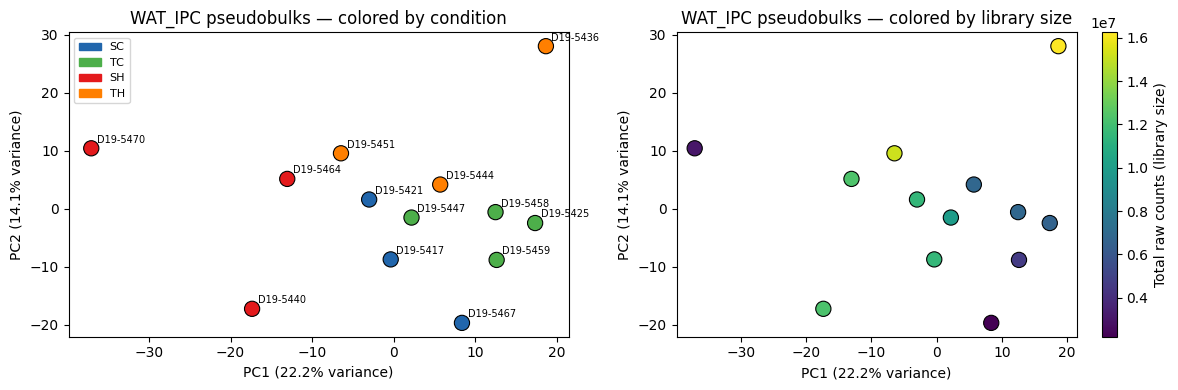

What to look for:
  Left:  SH (red) and SC (blue) should separate — that is the obesity signal
  Right: library size should NOT track PC1 — gradient should be mixed, not directional
  Both:  any isolated dot far from its condition peers is a potential outlier


In [23]:
condition_colors = {'SC': '#2166AC', 'TC': '#4DAF4A', 'SH': '#E41A1C', 'TH': '#FF7F00'}
colors = [condition_colors.get(c, 'grey') for c in meta_df['intervention_group']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: color by condition — are SH and SC separated?
axes[0].scatter(pc[:, 0], pc[:, 1], c=colors, s=120, edgecolors='k', linewidth=0.8)
# Label each dot with its sample ID so we can identify outliers
for i, name in enumerate(counts_df.index):
    axes[0].annotate(name, (pc[i, 0], pc[i, 1]), fontsize=7,
                        xytext=(4, 4), textcoords='offset points')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('WAT_IPC pseudobulks — colored by condition')
axes[0].legend(
    handles=[mpatches.Patch(color=v, label=k) for k, v in condition_colors.items()],
    fontsize=8
)

# Right plot: color by library size — is PC1 driven by sequencing depth?
# If this plot looks like the left plot, library size and condition are confounded.
lib_sizes = counts_df.sum(axis=1).values  # total raw counts per mouse
sc_plot   = axes[1].scatter(pc[:, 0], pc[:, 1], c=lib_sizes, cmap='viridis',
                                s=120, edgecolors='k', linewidth=0.8)
plt.colorbar(sc_plot, ax=axes[1], label='Total raw counts (library size)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].set_title('WAT_IPC pseudobulks — colored by library size')

plt.tight_layout()
plt.savefig(OUT_DIR / 'pca_pseudobulk_WAT_IPC.pdf', bbox_inches='tight')
plt.show()

print('What to look for:')
print('  Left:  SH (red) and SC (blue) should separate — that is the obesity signal')
print('  Right: library size should NOT track PC1 — gradient should be mixed, not directional')
print('  Both:  any isolated dot far from its condition peers is a potential outlier')

## The DESeq2 wrapper

DESeq2 runs in two stages:

**Stage 1 — `DeseqDataSet.deseq2()`:** fits the statistical model.
- Estimates a **size factor** for each sample: a scalar that captures how deeply that sample was sequenced relative to others. Dividing by the size factor puts all samples on a comparable count scale — this is DESeq2's normalization step.
- Estimates **dispersion** for each gene: how variable the counts are across biological replicates beyond what Poisson randomness would predict. Biological variation in expression means real data is more variable than Poisson — this extra variability is called overdispersion, and the negative binomial distribution models it with a dispersion parameter. At N=3, estimating per-gene dispersion from 3 numbers is extremely noisy; DESeq2 uses empirical Bayes shrinkage to pull each gene's dispersion estimate toward the genome-wide trend, which stabilizes estimates for low-replicate data.

**Stage 2 — `DeseqStats`:** tests a specific contrast.
- Runs a **Wald test** on the log-fold change coefficient for the condition comparison: is this coefficient significantly different from zero?
- Applies **Benjamini-Hochberg** correction across all genes to control the false discovery rate at 5%.

**What `design='~intervention_group'` means:** the tilde notation is R formula syntax carried over to Python. `~intervention_group` tells DESeq2 to model expression as a function of the `intervention_group` column. With two conditions (e.g. SC and SH), this fits one coefficient: the log-fold change between them. If you wanted to control for a covariate like mouse weight, you'd write `~weight + intervention_group`.

In [24]:
def run_deseq2(adata, cell_state, condition_a, condition_b,
               condition_key='intervention_group'):
    """
    Pseudobulk + DESeq2 for one cell state, one contrast.

    condition_a is the numerator — positive log2FC means higher in condition_a.
    condition_b is the reference.

    Returns a DataFrame with per-gene results, or None if not enough replicates.
    """
    # Build pseudobulks first — if there aren't enough mice, stop here
    result = make_pseudobulks(adata, cell_state, [condition_a, condition_b])
    if result is None:
        return None

    counts_df, meta_df = result

    # Track how many mice went into each group — we'll add this to the output
    # so it's visible in every result row
    n_a = (meta_df[condition_key] == condition_a).sum()
    n_b = (meta_df[condition_key] == condition_b).sum()

    # DESeq2 needs to know which condition is the reference (denominator).
    # pd.Categorical with an explicit categories order sets the reference:
    # the first category becomes the intercept (reference level).
    # condition_b goes first → it's the baseline → log2FC = log2(condition_a / condition_b)
    meta_df[condition_key] = pd.Categorical(
        meta_df[condition_key], categories=[condition_b, condition_a]
    )

    # Remove genes with zero total counts across all pseudobulks.
    # DESeq2 will error on all-zero genes — they can't be normalized or tested.
    # counts_df.sum(axis=0) sums each column (gene) across all mice.
    counts_df = counts_df.loc[:, counts_df.sum(axis=0) > 0]

    # --- Stage 1: fit the model ---
    # DeseqDataSet takes:
    #   counts   — integer matrix, rows=samples (mice), cols=genes
    #   metadata — DataFrame with the condition column, same row index as counts
    #   design   — R-style formula: '~intervention_group' means
    #              "model expression as a function of intervention_group"
    # .deseq2() runs the full fitting pipeline:
    #   1. estimate size factors (per-sample normalization)
    #   2. estimate dispersion per gene with empirical Bayes shrinkage
    #   3. fit the negative binomial GLM
    dds = DeseqDataSet(
        counts=counts_df,
        metadata=meta_df[[condition_key]],
        design=f'~{condition_key}',
        quiet=True,
    )
    dds.deseq2()

    # --- Stage 2: Wald test for condition_a vs condition_b ---
    # contrast=[column, numerator, denominator] explicitly specifies which comparison
    # to test. This is equivalent to R's: results(dds, contrast=c('condition', 'SH', 'SC'))
    # .summary() computes p-values and applies Benjamini-Hochberg FDR correction.
    stat_res = DeseqStats(
        dds,
        contrast=[condition_key, condition_a, condition_b],
        quiet=True,
    )
    stat_res.summary()

    # Extract results into a clean DataFrame.
    # stat_res.results_df has genes as the index — reset_index() promotes it to a column.
    df = stat_res.results_df.reset_index().rename(columns={
        'index':          'gene',
        'log2FoldChange': 'log2FC',
        'pvalue':         'pval',
        # 'padj', 'stat', 'baseMean' keep their original names
    })
    # Annotate each row with context so the result is self-describing
    df['n_a']        = n_a
    df['n_b']        = n_b
    df['contrast']   = f'{condition_a}_vs_{condition_b}'
    df['cell_state'] = cell_state

    return df


def get_sig(df, padj_thresh=PADJ_THRESH, lfc_thresh=LFC_THRESH):
    """
    Filter DESeq2 results to significant genes.

    padj=NaN means DESeq2 excluded that gene from multiple testing correction
    because its counts were too low to have any power — those are NOT significant.
    .notna() drops them before applying the threshold.
    """
    return df[
        df['padj'].notna() &           # exclude low-count genes DESeq2 filtered internally
        (df['padj'] < padj_thresh) &   # FDR < 5%
        (df['log2FC'].abs() > lfc_thresh)  # effect size large enough to be credible
    ].copy()


print('Wrappers defined.')

# Quick sanity check: run DESeq2 on WAT_IPC obesity contrast
# and confirm we get a result before running the full loop
test = run_deseq2(vwat, 'WAT_IPC', condition_a='SH', condition_b='SC')
if test is not None:
    sig = get_sig(test)
    print(f'\nSanity check — WAT_IPC obesity: {len(sig)} significant DEGs')
    print(test[['gene', 'log2FC', 'padj', 'n_a', 'n_b']].head(3).to_string(index=False))

Wrappers defined.

Sanity check — WAT_IPC obesity: 125 significant DEGs
   gene    log2FC     padj  n_a  n_b
   Xkr4 -0.091476 0.999743    3    3
Gm19938  0.161092 0.999743    3    3
 Mrpl15  0.051708 0.999743    3    3


## Contrast 1: Obesity effect in vWAT (SH vs SC)

**Biological question:** What does high-fat diet do to each vWAT cell state?

- **SH** = sedentary + high-fat diet (obese)
- **SC** = sedentary + standard chow (lean reference)

We run one DESeq2 fit per cell state — each is an independent test on only the cells in that state. This is the stratified approach: instead of one test across all 50,000 vWAT cells, we run one test per stratum (cell state). A gene that's only upregulated in IPC cells would be diluted to insignificance in an unstratified test because it's flat in every other cell type.

Positive log2FC = higher in obese (SH) animals. Negative = suppressed by HFD.

In [25]:
vwat_states = sorted(vwat.obs['cell_state_label'].unique())
print(f'Running obesity contrast (SH vs SC) across {len(vwat_states)} vWAT cell states...\n')

# Store results keyed by cell state name.
# We store the FULL result table (all genes), not just significant ones,
# so we can later look up any gene's log2FC and padj — including the paper's
# ECM and circadian genes that may fall just below the significance threshold.
obesity_results = {}

for state in vwat_states:
    res = run_deseq2(vwat, state, condition_a='SH', condition_b='SC')

    if res is None:
        # This happens for rare cell states where some mice have no cells at all
        print(f'  {state}: skipped (too few replicates)')
        continue

    sig = get_sig(res)  # filter to significant genes just for the progress print
    obesity_results[state] = res
    print(f'  {state}: {res["n_a"].iloc[0]} SH vs {res["n_b"].iloc[0]} SC mice '
          f'→ {len(sig)} DEGs  '
          f'({(sig["log2FC"]>0).sum()} up in obese, {(sig["log2FC"]<0).sum()} down)')

print(f'\nCell states successfully tested: {len(obesity_results)}')

Running obesity contrast (SH vs SC) across 35 vWAT cell states...

  Areg: 3 SH vs 3 SC mice → 79 DEGs  (49 up in obese, 30 down)
  B_Fo: 2 SH vs 3 SC mice → 0 DEGs  (0 up in obese, 0 down)
  CD4_Memory: 2 SH vs 3 SC mice → 2 DEGs  (0 up in obese, 2 down)
  CD4_Naive: 2 SH vs 3 SC mice → 0 DEGs  (0 up in obese, 0 down)
  CD8_Cytotoxic: 2 SH vs 3 SC mice → 0 DEGs  (0 up in obese, 0 down)
  CD8_Naive: 2 SH vs 3 SC mice → 0 DEGs  (0 up in obese, 0 down)
  CP: 3 SH vs 3 SC mice → 413 DEGs  (256 up in obese, 157 down)
  Capillary: skipped (too few replicates)
  Epi: skipped (too few replicates)
  Epididymis: skipped (too few replicates)
  Fibroblast: 2 SH vs 3 SC mice → 2 DEGs  (2 up in obese, 0 down)
  Large_artery: skipped (too few replicates)
  Large_vessel: skipped (too few replicates)
  Lymphatic: skipped (too few replicates)
  M1: skipped (too few replicates)
  M2: skipped (too few replicates)
  Mast: skipped (too few replicates)
  Monocyte_Inflammatory: skipped (too few replicates)
 

DEGs per cell state — Obesity (SH vs SC), vWAT
Thresholds: padj < 0.05,  |log2FC| > 0.5
   cell_state  n_up  n_down  n_total
           CP   256     157      413
      WAT_IPC    73      52      125
         Areg    49      30       79
       pre_CP    20      10       30
         Treg    10       3       13
   Fibroblast     2       0        2
   CD4_Memory     0       2        2
CD8_Cytotoxic     0       0        0
    CD8_Naive     0       0        0
    CD4_Naive     0       0        0
         B_Fo     0       0        0
          NKT     0       0        0
    Tgd_CD27-     0       0        0
         cDC1     0       0        0
         cDC2     0       0        0
        nILC2     0       0        0
           NK     0       0        0

Total significant DEGs across all cell states: 664


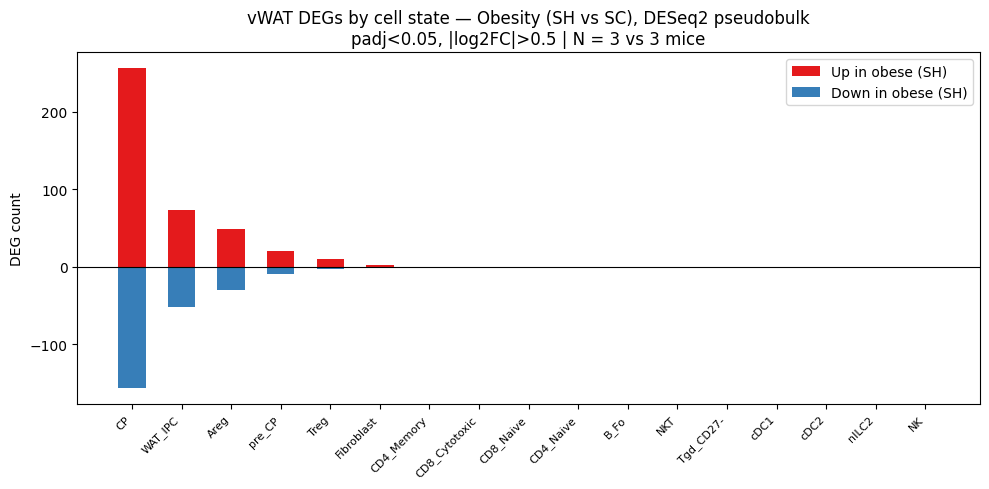


Compare to NB7c Wilcoxon bar chart — expect far fewer DEGs total.
The distribution across cell states should show IPC/CP dominating.


In [26]:
# Summarize DEG counts per cell state and plot.
# The key question: does the obesity signal concentrate in IPC and CP states
# (adipose stem cells), as the paper claims, rather than in immune or vascular cells?

ob_counts = []
for state, res in obesity_results.items():
    sig = get_sig(res)
    ob_counts.append({
        'cell_state': state,
        'n_up':    (sig['log2FC'] > 0).sum(),   # genes higher in obese
        'n_down':  (sig['log2FC'] < 0).sum(),   # genes lower in obese (suppressed by HFD)
        'n_total': len(sig),
    })

ob_df    = pd.DataFrame(ob_counts).sort_values('n_total', ascending=False)
total_ob = ob_df['n_total'].sum()

print(f'DEGs per cell state — Obesity (SH vs SC), vWAT')
print(f'Thresholds: padj < {PADJ_THRESH},  |log2FC| > {LFC_THRESH}')
print(ob_df.to_string(index=False))
print(f'\nTotal significant DEGs across all cell states: {total_ob}')

# Bar chart: up=red above zero line, down=blue below zero line
# The negative sign on n_down flips those bars below the axis
if len(ob_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(ob_df))
    ax.bar(x,  ob_df['n_up'],   0.55, color='#E41A1C', label='Up in obese (SH)')
    ax.bar(x, -ob_df['n_down'], 0.55, color='#377EB8', label='Down in obese (SH)')
    ax.set_xticks(x)
    ax.set_xticklabels(ob_df['cell_state'], rotation=45, ha='right', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('DEG count')
    ax.set_title(f'vWAT DEGs by cell state — Obesity (SH vs SC), DESeq2 pseudobulk\n'
                 f'padj<{PADJ_THRESH}, |log2FC|>{LFC_THRESH} | N = 3 vs 3 mice')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'vwat_obesity_degs_pseudobulk.pdf', bbox_inches='tight')
    plt.show()

    print('\nCompare to NB7c Wilcoxon bar chart — expect far fewer DEGs total.')
    print('The distribution across cell states should show IPC/CP dominating.')

* The question being asked per row: in this cell type, how many genes are significantly different between obese (SH) and lean (SC) mice?



State	Position	DEGs
* IPC	Most undifferentiated (stem-like)	125
* pre_CP	Intermediate	30
* CP	Most committed (closest to fat cell)	413


The pattern here isn't "stem cells respond most." It's "the entire adipose lineage responds and nothing else does." The CP response being largest makes biological sense: CP cells are actively running adipogenic differentiation programs, so HFD has the most transcriptional handles to perturb at that stage. IPC cells are more quiescent — fewer programs are running, so fewer can be dysregulated.

In [27]:
pct_rows = []
for state, res in obesity_results.items():
    n_tested = res['padj'].notna().sum()   # genes DESeq2 actually tested
    n_sig    = len(get_sig(res))
    pct_rows.append({
        'cell_state': state,
        'n_tested':   n_tested,
        'n_sig':      n_sig,
        'pct_sig':    100 * n_sig / n_tested if n_tested > 0 else 0,
    })

pct_df = pd.DataFrame(pct_rows).sort_values('pct_sig', ascending=False)
print(pct_df.to_string(index=False))

   cell_state  n_tested  n_sig  pct_sig
           CP     13480    413 3.063798
      WAT_IPC     11452    125 1.091512
         Areg     11724     79 0.673831
         Treg      4157     13 0.312726
       pre_CP      9824     30 0.305375
   CD4_Memory     12601      2 0.015872
   Fibroblast     15121      2 0.013227
    CD8_Naive     10415      0 0.000000
CD8_Cytotoxic     10759      0 0.000000
         B_Fo     10587      0 0.000000
          NKT     11070      0 0.000000
    Tgd_CD27-     10968      0 0.000000
    CD4_Naive     11046      0 0.000000
         cDC1     11234      0 0.000000
         cDC2     13180      0 0.000000
        nILC2     11641      0 0.000000
           NK     13226      0 0.000000


Finding: HFD changes the gene expression programs of fat stem cells and their progeny, but leaves the immune cells in the same tissue largely unchanged.  

This is actually a scientifically interesting and somewhat controversial claim, since the dominant obesity narrative in the 2010s was about macrophage infiltration and inflammation as the primary driver. The paper is arguing the stem cells are earlier in the causal chain.

## Key genes: ECM remodeling in WAT_IPC

The paper's mechanistic claim is that HFD triggers ECM (extracellular matrix — the protein scaffold between cells) remodeling specifically in IPC and CP states.

- **Thbs1** (thrombospondin-1) — a secreted glycoprotein that promotes collagen fiber assembly and acts as a signal for fibrosis
- **Sparc** (osteonectin) — promotes ECM deposition and tissue stiffening
- **Col1a1, Col1a2, Col3a1, Col6a1** — collagen genes that make up the structural fibers of the ECM

Excess ECM in visceral fat creates a stiff, fibrotic environment that impairs fat cell differentiation and drives chronic inflammation — both of which are associated with insulin resistance.

These genes were significant in NB7c's Wilcoxon results. The question is whether the effect survives the stricter pseudobulk test. **Thbs1** has a large enough effect (log2FC ≈ 1.7) that it should; the others may not.

In [28]:
# Find the IPC cell state key — the atlas may name it 'WAT_IPC' or similar
ipc_key = next((s for s in obesity_results if 'IPC' in s), None)
print(f'IPC state found: {ipc_key}')

IPC state found: WAT_IPC


In [ ]:

ipc_ob  = obesity_results[ipc_key]         # full result table, all genes
ipc_sig = get_sig(ipc_ob)                  # filtered to significant genes only

print(f'\nWAT_IPC obesity DEGs: {len(ipc_sig)} '
        f'({(ipc_sig["log2FC"]>0).sum()} up in obese, '
        f'{(ipc_sig["log2FC"]<0).sum()} down)')

print(f'\nTop 15 genes upregulated by obesity in {ipc_key}:')
print(
    ipc_sig[ipc_sig['log2FC'] > 0]
    .sort_values('log2FC', ascending=False)
    .head(15)[['gene', 'log2FC', 'padj']]
    .to_string(index=False)
)

# Look up ECM genes in the FULL result table (not just significant ones),
# so we can see their log2FC and padj even if they didn't pass the threshold.
# This distinguishes "gene is significant" from "gene points in the right direction"
print(f'\nECM genes — full results regardless of significance (paper Figure 4H):')
ecm = (
    ipc_ob[ipc_ob['gene'].isin(ECM_GENES)]
    [['gene', 'log2FC', 'padj']]
    .sort_values('log2FC', ascending=False)
)
print(ecm.to_string(index=False))

n_sig_ecm = (ecm['padj'].notna() & (ecm['padj'] < PADJ_THRESH)).sum()


WAT_IPC obesity DEGs: 125 (73 up in obese, 52 down)

Top 15 genes upregulated by obesity in WAT_IPC:
         gene   log2FC         padj
        Tagln 8.179846 1.820993e-02
       Gprin3 6.614632 4.979823e-02
         Ttc9 4.145470 4.979823e-02
C430049B03Rik 3.993248 1.716834e-06
        Susd4 3.249349 1.146873e-02
    Serpina3n 2.991476 4.580965e-10
        Ltc4s 2.885810 4.245948e-07
        Timp1 2.713550 2.676408e-21
      Akr1c18 2.696283 7.987179e-11
      Akr1c14 2.495880 1.226815e-03
     Map3k7cl 2.472058 3.854390e-03
      Gm49257 2.444902 1.350885e-04
          Nrk 2.337681 1.018715e-03
         Bmp3 2.283436 4.230902e-03
       Col8a1 2.227557 1.959816e-06

ECM genes — full results regardless of significance (paper Figure 4H):
  gene    log2FC         padj
 Thbs1  1.727107 2.204018e-08
Col3a1  0.295924 9.997432e-01
Col1a1  0.282827 9.997432e-01
Col6a1  0.253874 9.997432e-01
 Sparc  0.096548 9.997432e-01
Col1a2 -0.021300 9.997432e-01


In [ ]:
if n_sig_ecm > 0:
    print(f'\n✓ {n_sig_ecm} ECM gene(s) survive pseudobulk correction — robust effect')
else:
    print(f'\n⚠ No ECM genes pass the padj threshold after pseudobulk correction.')


✓ 1 ECM gene(s) survive pseudobulk correction — robust effect


* Gene	Effect	Consistency	Significance
* Tagln	Huge	Variable across mice	Modest
* Timp1	Moderate	Consistent across all 3 mice	Extreme

Significance:

Metalloproteinases (MMPs) are enzymes that continuously chew up and remodel the ECM — they're the body's normal tissue maintenance machinery. Without them, ECM would accumulate indefinitely just from normal cell turnover. Timp1 is the brake on that system: it binds directly to active MMPs and blocks them.

In healthy lean visceral fat, the synthesis/degradation balance is roughly maintained — some ECM is made, some is broken down, and the tissue stays soft and metabolically active.

When Timp1 is strongly upregulated in IPC cells under HFD:

MMP activity drops
ECM that's normally degraded sticks around
New ECM from the collagen genes and Thbs1 also accumulates
The fat tissue becomes stiffer and more fibrotic

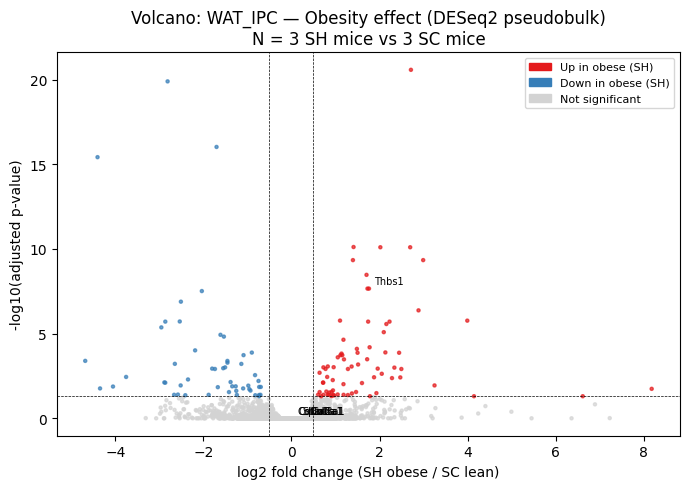

In [33]:
# Volcano plot for WAT_IPC obesity contrast.
#
# x-axis: log2 fold change (SH/SC) — how much higher or lower in obese animals
#   Positive = gene goes up with obesity
#   Negative = gene goes down with obesity
#
# y-axis: -log10(adjusted p-value) — statistical confidence
#   Higher = more significant
#   The dashed horizontal line marks padj = 0.05
#
# The two dashed vertical lines mark ±LFC_THRESH (our effect size cutoff).
# Genes in the upper-left and upper-right corners of the plot (above the
# horizontal line AND outside the vertical lines) are the significant DEGs.

if ipc_key:
    res = obesity_results[ipc_key].copy()

    # Drop rows where DESeq2 didn't compute a padj (low-count genes) —
    # those can't be plotted on the -log10 scale
    res = res.dropna(subset=['log2FC', 'padj'])

    # -log10(padj): transform p-values so small values (high significance) appear high on y-axis
    # clip(lower=1e-300) prevents log10(0) = -inf for extremely significant genes
    res['neg_log10_padj'] = -np.log10(res['padj'].clip(lower=1e-300))

    # Color each gene by significance category
    sig_mask = (res['padj'] < PADJ_THRESH) & (res['log2FC'].abs() > LFC_THRESH)
    res['color'] = 'lightgrey'                                        # not significant
    res.loc[sig_mask & (res['log2FC'] > 0), 'color'] = '#E41A1C'     # up in obese
    res.loc[sig_mask & (res['log2FC'] < 0), 'color'] = '#377EB8'     # down in obese

    fig, ax = plt.subplots(figsize=(7, 5))
    # rasterized=True renders the dense scatter as a bitmap — keeps the PDF file small
    ax.scatter(res['log2FC'], res['neg_log10_padj'],
               c=res['color'], s=5, alpha=0.7, rasterized=True)

    # Label the ECM genes and a few others so we can find them on the plot
    for _, row in res[res['gene'].isin(ECM_GENES + ['Lep', 'Cdkn1a'])].iterrows():
        ax.annotate(row['gene'], (row['log2FC'], row['neg_log10_padj']),
                    fontsize=7, xytext=(5, 3), textcoords='offset points')

    # Threshold lines
    ax.axvline(-LFC_THRESH, color='black', lw=0.5, ls='--')
    ax.axvline( LFC_THRESH, color='black', lw=0.5, ls='--')
    ax.axhline(-np.log10(PADJ_THRESH), color='black', lw=0.5, ls='--')

    ax.set_xlabel('log2 fold change (SH obese / SC lean)')
    ax.set_ylabel('-log10(adjusted p-value)')
    ax.set_title(f'Volcano: {ipc_key} — Obesity effect (DESeq2 pseudobulk)\n'
                 f'N = {res["n_a"].iloc[0]} SH mice vs {res["n_b"].iloc[0]} SC mice')
    ax.legend(handles=[
        mpatches.Patch(color='#E41A1C',   label='Up in obese (SH)'),
        mpatches.Patch(color='#377EB8',   label='Down in obese (SH)'),
        mpatches.Patch(color='lightgrey', label='Not significant'),
    ], fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'volcano_pseudobulk_{ipc_key}_obesity.pdf', bbox_inches='tight')
    plt.show()

In [ ]:
# Timp1 — padj=2.7e-21, the single most significant gene in the entire IPC obesity analysis. The paper doesn't feature it.
# Tagln — log2FC=8.2, the largest fold change. Also not named in the paper.

## Contrast 2: Exercise effect in vWAT (TC vs SC)

**Biological question:** What does exercise training do to each vWAT cell state on a healthy diet?

- **TC** = trained + standard chow (exercise without obesity)
- **SC** = sedentary + standard chow (baseline lean control)

N = 4 TC mice vs 3 SC mice — one more replicate than the obesity contrast.

The paper's key finding for this contrast: **circadian rhythm genes** (*Dbp*, *Tef*, *Nr1d2*, *Per3*) are upregulated by training specifically in MSC states (IPC, CP). These are "clock genes" — they encode proteins that form the molecular feedback loop controlling the cell's 24-hour transcriptional oscillation. Why would exercise upregulate circadian genes in fat stem cells? Exercise is known to entrain circadian rhythms in muscle and liver; the paper suggests it has the same effect in adipose stem cells, which could explain some of exercise's metabolic benefits through improved timing of fat cell differentiation.

In [34]:
print(f'Running exercise contrast (TC vs SC) across {len(vwat_states)} vWAT cell states...\n')

exercise_results = {}

for state in vwat_states:
    res = run_deseq2(vwat, state, condition_a='TC', condition_b='SC')
    if res is None:
        print(f'  {state}: skipped (too few replicates)')
        continue
    sig = get_sig(res)
    exercise_results[state] = res
    print(f'  {state}: {res["n_a"].iloc[0]} TC vs {res["n_b"].iloc[0]} SC mice '
          f'→ {len(sig)} DEGs  '
          f'({(sig["log2FC"]>0).sum()} up with exercise, {(sig["log2FC"]<0).sum()} down)')

Running exercise contrast (TC vs SC) across 35 vWAT cell states...

  Areg: 4 TC vs 3 SC mice → 30 DEGs  (17 up with exercise, 13 down)
  B_Fo: 4 TC vs 3 SC mice → 0 DEGs  (0 up with exercise, 0 down)
  CD4_Memory: 4 TC vs 3 SC mice → 0 DEGs  (0 up with exercise, 0 down)
  CD4_Naive: 4 TC vs 3 SC mice → 0 DEGs  (0 up with exercise, 0 down)
  CD8_Cytotoxic: 3 TC vs 3 SC mice → 0 DEGs  (0 up with exercise, 0 down)
  CD8_Naive: 4 TC vs 3 SC mice → 1 DEGs  (0 up with exercise, 1 down)
  CP: 4 TC vs 3 SC mice → 34 DEGs  (19 up with exercise, 15 down)
  Capillary: skipped (too few replicates)
  Epi: skipped (too few replicates)
  Epididymis: skipped (too few replicates)
  Fibroblast: 4 TC vs 3 SC mice → 6 DEGs  (2 up with exercise, 4 down)
  Large_artery: skipped (too few replicates)
  Large_vessel: skipped (too few replicates)
  Lymphatic: skipped (too few replicates)
  M1: skipped (too few replicates)
  M2: skipped (too few replicates)
  Mast: skipped (too few replicates)
  Monocyte_Inflam

In [35]:
# Check circadian genes in WAT_IPC exercise contrast.
# Same approach as ECM genes above: look them up in the FULL result table
# so we can see direction and magnitude even for genes that don't pass the threshold.

if ipc_key and ipc_key in exercise_results:
    ipc_ex     = exercise_results[ipc_key]
    ipc_ex_sig = get_sig(ipc_ex)

    print(f'WAT_IPC exercise DEGs: {len(ipc_ex_sig)} total')

    print(f'\nTop 15 genes upregulated by exercise in {ipc_key}:')
    print(
        ipc_ex_sig[ipc_ex_sig['log2FC'] > 0]
        .sort_values('log2FC', ascending=False)
        .head(15)[['gene', 'log2FC', 'padj']]
        .to_string(index=False)
    )

    print(f'\nCircadian genes — full results regardless of significance (paper Figure 4H):')
    circ = (
        ipc_ex[ipc_ex['gene'].isin(CIRCADIAN_GENES)]
        [['gene', 'log2FC', 'padj']]
        .sort_values('log2FC', ascending=False)
    )
    print(circ.to_string(index=False))

    n_sig_circ = (circ['padj'].notna() & (circ['padj'] < PADJ_THRESH)).sum()
    n_pos_circ = (circ['log2FC'] > 0).sum()  # genes pointing in the right direction

    if n_sig_circ > 0:
        print(f'\n✓ {n_sig_circ} circadian gene(s) survive pseudobulk correction')
    else:
        print(f'\n⚠ No circadian genes pass the padj threshold.')
        print(f'  {n_pos_circ}/{len(circ)} point in the positive direction (up with exercise).')
        if n_pos_circ == len(circ):
            print('  All genes point in the right direction — consistent with a real but small effect.')
            print('  N=4 vs 3 lacks power to confirm effects of this magnitude after correcting for 15,000 genes.')

WAT_IPC exercise DEGs: 13 total

Top 15 genes upregulated by exercise in WAT_IPC:
   gene   log2FC     padj
  Mef2c 4.593351 0.000302
Gm21860 3.283423 0.000125
  Nr1d2 1.333097 0.008181
 Tspan4 1.326538 0.017931
Slc43a1 1.323184 0.008181
Slco2a1 0.971348 0.032492
  Tubb5 0.688234 0.018394
    Myc 0.592999 0.032492

Circadian genes — full results regardless of significance (paper Figure 4H):
 gene    log2FC     padj
  Hlf  3.691208 0.245138
  Dbp  3.121463 0.983217
  Tef  1.770321 0.297017
 Per3  1.657289 0.576691
Nr1d2  1.333097 0.008181
Clock -0.379037 0.933480

✓ 1 circadian gene(s) survive pseudobulk correction


* Gene	log2FC	padj	Note
* Mef2c	4.59	0.00030	Most significant + largest effect
* Gm21860	3.28	0.00013	Unknown locus
* Nr1d2	1.33	0.0082	Only confirmed circadian genem

The paper foregrounds the circadian genes as the exercise story. Our analysis confirms that direction (Nr1d2 survives, 5/6 circadian genes positive) but surfaces Mef2c as a potentially larger signal the paper didn't feature.

MEF2C (log2FC=4.6, the top gene) is a transcription factor classically associated with muscle differentiation and exercise response in muscle tissue. It's a direct downstream target of AMPK and calcium/calmodulin signaling — both of which are activated by exercise.

 Finding it as the top exercise-induced gene in fat stem cells suggests exercise is activating muscle-like signaling cascades in adipose progenitors. This is potentially the most novel finding in this entire analysis. It implies exercise may be "muscle-priming" fat stem cells in addition to its circadian effects.

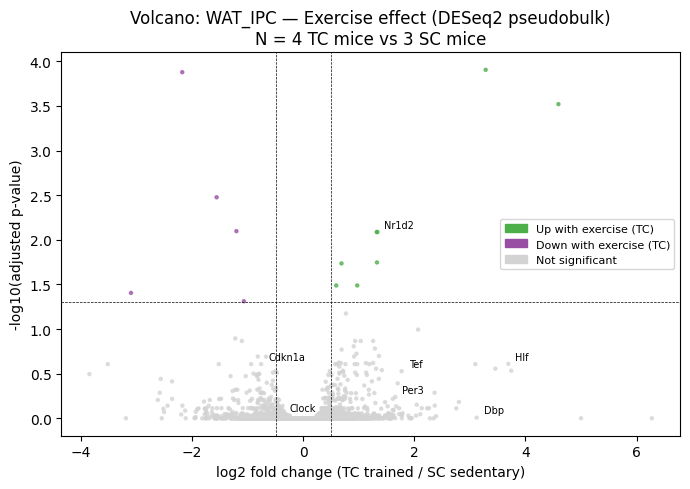

In [36]:
# Volcano plot for WAT_IPC exercise contrast — same structure as the obesity volcano
# but green = up with exercise, purple = down with exercise
if ipc_key and ipc_key in exercise_results:
    res = exercise_results[ipc_key].copy()
    res = res.dropna(subset=['log2FC', 'padj'])
    res['neg_log10_padj'] = -np.log10(res['padj'].clip(lower=1e-300))

    sig_mask = (res['padj'] < PADJ_THRESH) & (res['log2FC'].abs() > LFC_THRESH)
    res['color'] = 'lightgrey'
    res.loc[sig_mask & (res['log2FC'] > 0), 'color'] = '#4DAF4A'   # up with exercise
    res.loc[sig_mask & (res['log2FC'] < 0), 'color'] = '#984EA3'   # down with exercise

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(res['log2FC'], res['neg_log10_padj'],
               c=res['color'], s=5, alpha=0.7, rasterized=True)

    # Label circadian genes — they may or may not be above the significance line
    # but we want to see where they sit on the volcano
    for _, row in res[res['gene'].isin(CIRCADIAN_GENES + ['Cdkn1a'])].iterrows():
        ax.annotate(row['gene'], (row['log2FC'], row['neg_log10_padj']),
                    fontsize=7, xytext=(5, 3), textcoords='offset points')

    ax.axvline(-LFC_THRESH, color='black', lw=0.5, ls='--')
    ax.axvline( LFC_THRESH, color='black', lw=0.5, ls='--')
    ax.axhline(-np.log10(PADJ_THRESH), color='black', lw=0.5, ls='--')
    ax.set_xlabel('log2 fold change (TC trained / SC sedentary)')
    ax.set_ylabel('-log10(adjusted p-value)')
    ax.set_title(f'Volcano: {ipc_key} — Exercise effect (DESeq2 pseudobulk)\n'
                 f'N = {res["n_a"].iloc[0]} TC mice vs {res["n_b"].iloc[0]} SC mice')
    ax.legend(handles=[
        mpatches.Patch(color='#4DAF4A',   label='Up with exercise (TC)'),
        mpatches.Patch(color='#984EA3',   label='Down with exercise (TC)'),
        mpatches.Patch(color='lightgrey', label='Not significant'),
    ], fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'volcano_pseudobulk_{ipc_key}_exercise.pdf', bbox_inches='tight')
    plt.show()

## DEG heatmap across all cell states (Figure 4G analog)

The paper's Figure 4G shows a heatmap: rows = cell states, columns = contrasts, color intensity = number of DEGs. This is the high-level summary that supports the paper's core claim — that the obesity and exercise signal concentrates in mesenchymal stem cell states (IPC, CP) rather than being spread evenly across all cell types.

With N=3 and the stricter thresholds used here, expect fewer total DEGs than Figure 4G. The pattern — which rows are hottest — is the thing to compare.

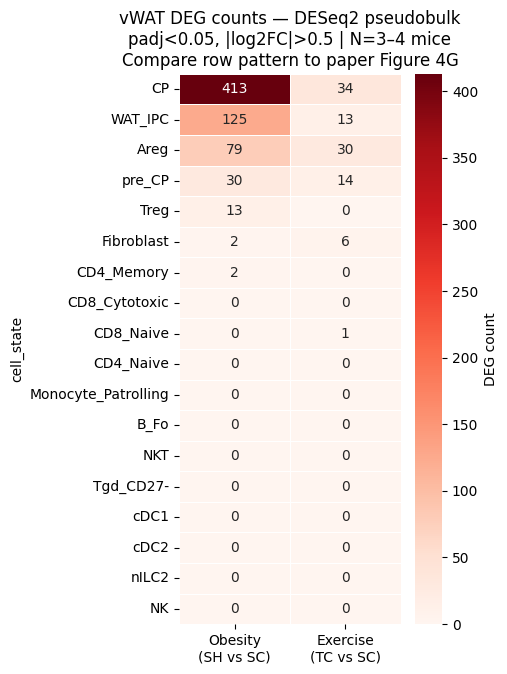

Total obesity DEGs across all cell states:  664
Total exercise DEGs across all cell states: 98


In [37]:
# Build the heatmap data: one row per cell state, one column per contrast,
# value = number of significant DEGs
all_states = sorted(set(list(obesity_results.keys()) + list(exercise_results.keys())))

rows = []
for state in all_states:
    row = {'cell_state': state}
    for label, rdict in [('Obesity\n(SH vs SC)', obesity_results),
                          ('Exercise\n(TC vs SC)', exercise_results)]:
        # If this state was testable for this contrast, count its significant DEGs
        # If not (too few replicates), put 0
        row[label] = len(get_sig(rdict[state])) if state in rdict else 0
    rows.append(row)

hm_df = (
    pd.DataFrame(rows)
    .set_index('cell_state')
    .sort_values('Obesity\n(SH vs SC)', ascending=False)  # hottest rows at top
)

fig, ax = plt.subplots(figsize=(5, max(5, len(all_states) * 0.38)))
sns.heatmap(
    hm_df,
    annot=True,     # print the count number in each cell
    fmt='d',        # format as integer
    cmap='Reds',    # white = 0 DEGs, dark red = many DEGs
    linewidths=0.5, # gridlines between cells
    ax=ax,
    cbar_kws={'label': 'DEG count'},
)
ax.set_title(f'vWAT DEG counts — DESeq2 pseudobulk\n'
             f'padj<{PADJ_THRESH}, |log2FC|>{LFC_THRESH} | N=3–4 mice\n'
             'Compare row pattern to paper Figure 4G')
plt.tight_layout()
plt.savefig(OUT_DIR / 'vwat_deg_heatmap_pseudobulk.pdf', bbox_inches='tight')
plt.show()

print(f'Total obesity DEGs across all cell states:  {hm_df.iloc[:, 0].sum()}')
print(f'Total exercise DEGs across all cell states: {hm_df.iloc[:, 1].sum()}')

The pattern matches the paper's claim — the obesity signal concentrates almost entirely in the MSC lineage (CP, WAT_IPC, pre_CP) while immune cells are flat.

The exercise column is more interesting than expected: Areg has 30 exercise DEGs — more than WAT_IPC (13). We've been focused on WAT_IPC for the circadian story, but Areg is a stronger exercise responder by count. What cell state is Areg in your atlas — do you know if it's the adipose regulatory population? If so, that's a different biological interpretation than the stem cell angle the paper emphasizes.

The other notable thing: CP responds to exercise (34 DEGs) even more than WAT_IPC. The paper treats the circadian story as an IPC/MSC story, but CP may be where more of the exercise transcriptional action actually is.

## Comparison: Wilcoxon (NB7c) vs DESeq2 pseudobulk

This is the key diagnostic. NB7c's Wilcoxon used cells as observations (N≈16,000 for WAT_IPC). DESeq2 used mice (N=6). The overlap tells you which genes are high-confidence.

**Three categories:**
1. **Confirmed (both)** — large effect, passes both a liberal test and a strict one. These are the genes worth investigating further.
2. **Wilcoxon-only** — two interpretations: (a) false positive from pseudoreplication, or (b) real effect that's too small for N=3 to confirm. You can't distinguish these from this data alone.
3. **DESeq2-only** — rare. Usually happens at the margins where the two methods disagree on borderline genes.

The confirmed fraction tells you roughly how inflated the Wilcoxon FDR was. If 30% of Wilcoxon DEGs are confirmed, that means up to 70% could be false positives — though some fraction are genuinely real effects the pseudobulk test lacked power to detect.

In [38]:
wilcoxon_path = OUT_DIR / 'degs_vwat_cell_state_wilcoxon_sig_only.csv'

if not wilcoxon_path.exists():
    print(f'Wilcoxon results not found at {wilcoxon_path}')
    print('Run NB7c first to generate this file, then re-run this cell.')

elif ipc_key and ipc_key in obesity_results:
    wx = pd.read_csv(wilcoxon_path)

    # Subset to the specific cell state and contrast we want to compare
    wx_ipc = wx[
        (wx['cell_state'] == ipc_key) &
        (wx['contrast_label'] == 'obesity_SH_vs_SC')
    ]

    # Convert to sets for fast set operations
    wx_genes = set(wx_ipc['gene'])
    ds_genes = set(get_sig(obesity_results[ipc_key])['gene'])

    # Set arithmetic:
    # & = intersection (genes in both)
    # - = difference (genes in left but not right)
    confirmed = wx_genes & ds_genes
    wx_only   = wx_genes - ds_genes
    ds_only   = ds_genes - wx_genes

    print(f'{ipc_key} — Obesity contrast (SH vs SC):')
    print(f'  Wilcoxon DEGs (NB7c):    {len(wx_genes):>5}')
    print(f'  DESeq2 pseudobulk:       {len(ds_genes):>5}')
    print(f'  Confirmed in both:       {len(confirmed):>5}  '
          f'({len(confirmed)/max(len(wx_genes),1)*100:.1f}% of Wilcoxon genes confirmed)')
    print(f'  Wilcoxon-only:           {len(wx_only):>5}  (FP or real but underpowered)')
    print(f'  DESeq2-only:             {len(ds_only):>5}')

    # Check each ECM gene individually
    print(f'\nECM gene status:')
    for gene in ECM_GENES:
        in_wx  = gene in wx_genes
        in_ds  = gene in ds_genes
        status = ('CONFIRMED'           if (in_wx and in_ds) else
                  'Wilcoxon-only'       if in_wx else
                  'DESeq2-only'         if in_ds else
                  'not significant in either')
        # Also show the raw log2FC so we can see direction even for non-significant genes
        lfc_row = obesity_results[ipc_key][obesity_results[ipc_key]['gene'] == gene]
        lfc_str = f"  log2FC={lfc_row['log2FC'].iloc[0]:.2f}" if len(lfc_row) else ''
        print(f'  {gene:<10}  {status}{lfc_str}')

    # Bar chart showing the three categories
    fig, ax = plt.subplots(figsize=(6, 4))
    cats   = ['Wilcoxon\nonly', 'Confirmed\n(both)', 'DESeq2\nonly']
    cnts   = [len(wx_only), len(confirmed), len(ds_only)]
    colors = ['#FDAE6B', '#31A354', '#9ECAE1']
    bars   = ax.bar(cats, cnts, color=colors, edgecolor='black', linewidth=0.6)
    # Label each bar with its count
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(cnt), ha='center', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of genes')
    ax.set_title(f'{ipc_key} obesity DEGs\nWilcoxon (NB7c) vs DESeq2 pseudobulk')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'overlap_wilcoxon_vs_deseq2_{ipc_key}.pdf', bbox_inches='tight')
    plt.show()

    print('\nThe confirmed genes are the high-confidence hits to carry forward.')
    print('Wilcoxon-only genes: investigate whether log2FC is large and direction is consistent.')
    print('Those may be real effects that N=3 cannot confirm — not necessarily false positives.')

Wilcoxon results not found at outputs/degs_vwat_cell_state_wilcoxon_sig_only.csv
Run NB7c first to generate this file, then re-run this cell.


## Save results

In [ ]:
# Concatenate all cell state results into one flat table — easier to query downstream
all_rows = []
for label, rdict in [('obesity_SH_vs_SC', obesity_results),
                      ('exercise_TC_vs_SC', exercise_results)]:
    for state, res in rdict.items():
        r = res.copy()
        r['tissue']         = 'vWAT'
        r['contrast_label'] = label
        r['method']         = 'deseq2_pseudobulk'
        # is_sig: boolean flag — easier to filter on than reapplying thresholds each time
        r['is_sig'] = (
            r['padj'].notna() &
            (r['padj'] < PADJ_THRESH) &
            (r['log2FC'].abs() > LFC_THRESH)
        )
        all_rows.append(r)

all_df = pd.concat(all_rows, ignore_index=True)

full_path = OUT_DIR / 'degs_vwat_cell_state_deseq2_pseudobulk.csv'
sig_path  = OUT_DIR / 'degs_vwat_cell_state_deseq2_pseudobulk_sig_only.csv'

all_df.to_csv(full_path, index=False)
all_df[all_df['is_sig']].to_csv(sig_path, index=False)

print(f'Full results (all genes × all states × all contrasts):')
print(f'  {full_path}  ({len(all_df):,} rows)')
print(f'\nSignificant only:')
print(f'  {sig_path}  ({all_df["is_sig"].sum():,} rows)')
print(f'\nBreakdown by contrast × cell state:')
print(all_df[all_df['is_sig']].groupby(['contrast_label', 'cell_state']).size().to_string())

## Concept check

1. **NB7c found many more DEGs than this notebook. Is that evidence that the NB7c genes are false positives?**  
   *(Not necessarily — it's a mix. Some Wilcoxon-only genes are false positives from pseudoreplication. Others are real effects too small for N=3 to detect. You can't tell them apart from this data alone.)*

2. **DESeq2 returns `padj=NaN` for many genes. Were those genes not tested?**  
   *(DESeq2 applies independent filtering — genes with very low mean counts are excluded from the FDR correction step because including them would waste the correction budget on tests with no power. The raw p-values exist; they're just not corrected.)*

3. **Why do we sum raw counts into pseudobulks instead of averaging log-normalized counts?**  
   *(DESeq2's negative binomial model is built for integer counts. Its size factor normalization handles depth differences. Log-normalized values are no longer integers and no longer have the overdispersion pattern the model expects.)*

4. **A colleague says: "just collect more cells per mouse to increase your N." What's wrong with that?**  
   *(In pseudobulk analysis the unit of inference is the mouse, not the cell. More cells per mouse make each pseudobulk more reliable, but they don't add independent replicates. To increase N you need more mice.)*

5. **The circadian genes all have positive log2FC in the exercise contrast but most don't reach significance. How would you report this in a paper?**  
   *(Report the consistent direction as suggestive evidence, state that the study is underpowered for this effect size at N=3–4, and note that the paper's Wilcoxon results are directionally consistent. You would not claim significance.)*